# Segmentation Tracking with DINOv3

This notebook demonstrates using DINOv3 for video segmentation tracking
using a non-parametric method similar to
["Space-time correspondence as a contrastive random walk" (Jabri et al. 2020)](https://arxiv.org/abs/2006.14613).

Given:
- RGB video frames
- Instance segmentation masks for the first frame

We will extract patch features from each frame and use patch similarity
to propagate the ground-truth labels to all frames.

## Setup

Let's start by loading some pre-requisites, setting up the environment and checking the DINOv3 repository location:
- `local` if `DINOV3_LOCATION` environment variable was set to work with a local version of DINOv3 repository;
- `github` if the code should be loaded via torch hub.

In [ ]:
import datetime
import functools
import io
import logging
import math
import os
import sys
from pathlib import Path
import time

import lovely_tensors
import matplotlib.pyplot as plt
import mediapy as mp
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
import torchvision.transforms as TVT
import torchvision.transforms.functional as TVTF
from torch import Tensor, nn
from tqdm import tqdm

# ── repo 경로 등록 (inspection/, dinov3 패키지 import 용) ──────────────────
#   이 노트북은 dino_v3/notebooks/ 에 있으므로 repo 루트는 parents[2].
_REPO = Path.cwd()
for _cand in [Path.cwd(), *Path.cwd().parents]:
    if (_cand / "inspection").is_dir() and (_cand / "dino_v3").is_dir():
        _REPO = _cand
        break
for _p in (str(_REPO), str(_REPO / "dino_v3")):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print(f"repo root: {_REPO}")

import dinov3.distributed as distributed  # noqa: E402
from dinov3.eval.setup import setup_and_build_model  # noqa: E402
from inspection.em_aug import PerImageNormalize  # noqa: E402

DISPLAY_HEIGHT = 200
lovely_tensors.monkey_patch()
torch.set_grad_enabled(False)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  설정 — 여기 네 칸만 채우면 됩니다. (아래 셀들은 이 변수들을 그대로 사용)
# ══════════════════════════════════════════════════════════════════════════

# 1) domain-finetuned ViT-B 체크포인트 (teacher .pth) 와 학습에 쓴 config
CONFIG_FILE = str(_REPO / "dino_v3/dinov3/configs/train/weaksup/stage2_ssl_weaksup.yaml")
PRETRAINED_WEIGHTS = "/path/to/vitb_domain_finetuned_teacher.pth"

# 2) 연속 프레임 이미지들이 든 폴더 (파일명 자연 정렬 순서로 전부 로드)
#    특정 파일만/순서를 직접 지정하려면 FRAME_PATHS 에 리스트를 넣으세요.
FRAMES_DIR = "/path/to/frames"
FRAME_PATHS: list[str] | None = None  # 예: ["/d/f/000.png", "/d/f/001.png", ...]

# 3) 첫 프레임 객체 마스크 PNG (0=배경, 1,2,3,...=객체). frames[0] 원본 해상도와 동일해야 함.
FIRST_MASK_PATH = "/path/to/first_frame_mask.png"

# 4) 결과 저장 폴더 (setup 로그/산출물)
OUTPUT_DIR = "./out/segtrack"

IMG_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

# ── 사전 점검: 무거운 모델 로드 전에 경로부터 확인 ─────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)


def _resolve_frame_paths() -> list[str]:
    if FRAME_PATHS is not None:
        return list(FRAME_PATHS)
    import re
    d = Path(FRAMES_DIR)
    assert d.is_dir(), f"FRAMES_DIR 폴더가 없습니다: {FRAMES_DIR}"
    def _key(p: Path):
        return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", p.name)]
    return [str(p) for p in sorted(
        (q for q in d.iterdir() if q.suffix.lower() in IMG_EXTS), key=_key
    )]


_problems = []
if not Path(CONFIG_FILE).is_file():
    _problems.append(f"CONFIG_FILE 없음: {CONFIG_FILE}")
if not Path(PRETRAINED_WEIGHTS).is_file():
    _problems.append(f"PRETRAINED_WEIGHTS 없음: {PRETRAINED_WEIGHTS}")
if not Path(FIRST_MASK_PATH).is_file():
    _problems.append(f"FIRST_MASK_PATH 없음: {FIRST_MASK_PATH}")

_frame_paths = []
try:
    _frame_paths = _resolve_frame_paths()
    if len(_frame_paths) == 0:
        _problems.append(f"프레임 이미지를 못 찾음 (폴더는 있으나 이미지 0장): {FRAMES_DIR}")
except AssertionError as e:
    _problems.append(str(e))

if _problems:
    print("⚠️  아래를 먼저 해결하세요:")
    for p in _problems:
        print("   -", p)
else:
    print("✅ 경로 점검 통과")
    print(f"   config     : {CONFIG_FILE}")
    print(f"   weights    : {PRETRAINED_WEIGHTS}")
    print(f"   frames     : {len(_frame_paths)}장  (첫: {Path(_frame_paths[0]).name}, 끝: {Path(_frame_paths[-1]).name})")
    print(f"   first mask : {FIRST_MASK_PATH}")
    print(f"   output     : {OUTPUT_DIR}")

## Model

We load the DINOv3 ViT-L model and get some attributes. Feel free to try other DINOv3 models as well!

In [ ]:
# ── domain-finetuned ViT-B 로드 (repo 표준 방식) ──────────────────────────
#   경로는 위 "설정" 셀에서 가져옴. torch.hub 대신 setup_and_build_model 사용.
if not distributed.is_enabled():
    distributed.enable(overwrite=True)

model, ctx = setup_and_build_model(
    config_file=CONFIG_FILE,
    pretrained_weights=PRETRAINED_WEIGHTS,
    output_dir=OUTPUT_DIR,
)
model.cuda().eval()
autocast_dtype = ctx["autocast_dtype"]

patch_size = model.patch_size
embed_dim = model.embed_dim
print(f"Patch size: {patch_size}")
print(f"Embedding dimension: {embed_dim}")
print(f"Peak GPU memory: {torch.cuda.max_memory_allocated() / 2**30:.1f} GB")

We want to process one image at the time and get L2-normalized features.
Here is a wrapper to do just that.

In [ ]:
@torch.inference_mode()
def forward(
    model: nn.Module,
    img: Tensor,  # [3, H, W] already normalized for the model
) -> Tensor:
    with torch.autocast("cuda", dtype=autocast_dtype):
        # norm=True: 학습/few-shot 에서 쓰는 정규화된 patch 토큰과 동일하게 맞춤
        feats = model.get_intermediate_layers(
            img.unsqueeze(0), n=1, reshape=True, norm=True
        )[0]  # [1, D, h, w]
    feats = feats.movedim(-3, -1).float()  # [1, h, w, D]
    feats = F.normalize(feats, dim=-1, p=2)  # patch feature L2 정규화 (코사인 유사도용)
    return feats.squeeze(0)  # [h, w, D]

## Data

Here we load the video frames and the instance segmentation masks for the first frame.

이 노트북은 **연속된 이미지 파일들**을 프레임으로 사용합니다 (mp4 불필요).

- `FRAMES_DIR` 에 이미지 폴더를 지정하면 파일명 자연 정렬 순서로 전부 로드하거나,
- `FRAME_PATHS` 에 파일 경로 리스트를 직접 넘겨 순서를 지정할 수 있습니다.

> **주의**: 이 방법은 라벨 *전파(propagation)* 라서 프레임들이 서로 이어지는(인접 프레임끼리 객체가 조금씩만 움직이는) 시퀀스여야 잘 동작합니다. 서로 무관한 이미지 집합에는 적합하지 않습니다.

`.mp4` 에서 프레임을 뽑고 싶다면 `ffmpeg` 로 먼저 추출하세요:
```bash
ffmpeg -hide_banner -i video.mp4 -qscale:v 2 -vf fps=24 -y "frames/%06d.jpg"
```

In [ ]:
# ── 프레임 로딩 (경로/순서는 위 "설정" 셀에서 이미 확정됨) ──────────────────
FRAME_PATHS = _resolve_frame_paths()  # 폴더면 자연 정렬, 리스트면 그 순서
assert len(FRAME_PATHS) > 0, "프레임을 찾지 못했습니다. 설정 셀을 확인하세요."

frames = [Image.open(p).convert("RGB") for p in FRAME_PATHS]
num_frames = len(frames)
print(f"Number of frames: {num_frames}")
print(f"First: {FRAME_PATHS[0]}")
print(f"Last:  {FRAME_PATHS[-1]}")

original_width, original_height = frames[0].size
print(f"Original size: width={original_width}, height={original_height}")

Let's show four sample frames from the video:

Frame 0,Frame 57,Frame 115,Frame 173

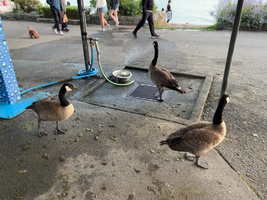
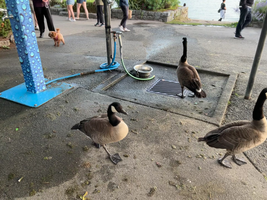
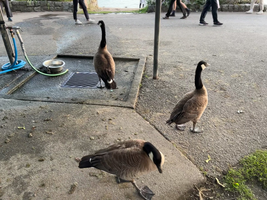
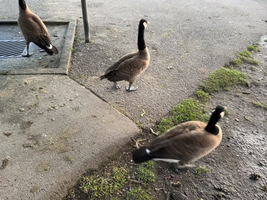

In [5]:
num_selected_frames = 4
selected_frames = np.linspace(0, num_frames - 1, num_selected_frames, dtype=int)

mp.show_images(
    [frames[int(i)] for i in selected_frames],
    titles=[f"Frame {i}" for i in selected_frames],
    height=DISPLAY_HEIGHT,
)

This notebook assumes that instance segmentation masks for the first frame are stored in a `.png` file:
- A value of `0` indicates the background.
- Object instances are represented by progressive contiguous `uint8` indices starting from `1`.

We created the example mask using [SAM 2](), but Paint would work just as well.

A function to visualize the masks as RGB is also provided.

In [ ]:
def mask_to_rgb(mask: np.ndarray | Tensor, num_masks: int) -> np.ndarray:
    if isinstance(mask, Tensor):
        mask = mask.cpu().numpy()

    # Exclude background
    background = mask == 0
    mask = mask - 1
    num_masks = num_masks - 1

    # Choose palette
    if num_masks <= 10:
        mask_rgb = plt.get_cmap("tab10")(mask)[..., :3]
    elif num_masks <= 20:
        mask_rgb = plt.get_cmap("tab20")(mask)[..., :3]
    else:
        mask_rgb = plt.get_cmap("gist_rainbow")(mask / (num_masks - 1))[..., :3]

    mask_rgb = (mask_rgb * 255).astype(np.uint8)
    mask_rgb[background, :] = 0
    return mask_rgb


# ── 첫 프레임(=frames[0]) 의 객체 마스크 PNG 로드 (경로는 "설정" 셀에서) ──────
#   PNG 규칙: 0=배경, 1,2,3,... = 객체 인스턴스 (연속 uint8 인덱스).
#   이 마스크가 곧 "어떤 객체를 추적할지"의 선택. SAM2/Paint/라벨툴 무엇으로 만들든 무방.
first_mask_np = np.array(Image.open(FIRST_MASK_PATH))
if first_mask_np.ndim == 3:  # RGB/RGBA 로 저장된 경우 첫 채널만 사용
    first_mask_np = first_mask_np[..., 0]
first_mask_np = first_mask_np.astype(np.uint8)

mask_height, mask_width = first_mask_np.shape  # Abbreviated at [H', W']
print(f"Mask size: {[mask_height, mask_width]}")
assert (mask_height, mask_width) == (original_height, original_width), (
    f"마스크 해상도 {first_mask_np.shape} 가 첫 프레임 {(original_height, original_width)} 과 다릅니다."
)

num_masks = int(first_mask_np.max() + 1)  # Abbreviated as M (배경 포함 라벨 수)
print(f"Number of masks (배경 포함): {num_masks}")

mp.show_images(
    [frames[0], mask_to_rgb(first_mask_np, num_masks)],
    titles=["Frame", "Mask"],
    height=DISPLAY_HEIGHT,
)

Time for some math! Input frames need to be resized to match the desired forward resolution and the model patch size.

The desired forward resolution refers to the _short side_ of the input.
If the desired resolution is not a multiple of the patch size, we simply round it up.
Then, we determine the _long side_ by maintaining the original aspect ratio as much as possible, but rounding up to the patch size as well.

With the occasion, we'll also setup the torchvision transforms and test them out on the first frame.

In [ ]:
class ResizeToMultiple(nn.Module):
    def __init__(self, short_side: int, multiple: int):
        super().__init__()
        self.short_side = short_side
        self.multiple = multiple

    def _round_up(self, side: float) -> int:
        return math.ceil(side / self.multiple) * self.multiple

    def forward(self, img):
        old_width, old_height = TVTF.get_image_size(img)
        if old_width > old_height:
            new_height = self._round_up(self.short_side)
            new_width = self._round_up(old_width * new_height / old_height)
        else:
            new_width = self._round_up(self.short_side)
            new_height = self._round_up(old_height * new_width / old_width)
        return TVTF.resize(img, [new_height, new_width], interpolation=TVT.InterpolationMode.BICUBIC)


SHORT_SIDE = 960

# ★ finetuned 모델은 ImageNet 통계가 아니라 학습과 동일한 per-image(instance) 정규화를 씀.
#   (PerImageNormalize: (C,H,W) → zero-mean/unit-std, ImageNet Normalize 아님)
transform = TVT.Compose(
    [
        ResizeToMultiple(short_side=SHORT_SIDE, multiple=patch_size),
        TVT.ToTensor(),
        PerImageNormalize(),
    ]
)
first_frame = transform(frames[0]).to("cuda")
print(f"First frame: {first_frame}")

_, frame_height, frame_width = first_frame.shape  # Abbreviated as [H, W]
feats_height, feats_width = frame_height // patch_size, frame_width // patch_size  # Abbreviated as [h, w]

Label propagation happens at the output resolution of the model,
so we downsample the ground-truth masks of the first frame and turn them into a one-hot probability map.

In [8]:
first_mask = torch.from_numpy(first_mask_np).to("cuda", dtype=torch.long)  # [H', W']
first_mask = F.interpolate(
    first_mask[None, None, :, :].float(),  # [1, 1, H', W']
    (feats_height, feats_width),
    mode="nearest-exact",
)[0, 0].long()  # [h, w]
print(f"First mask:  {first_mask}")

first_probs = F.one_hot(first_mask, num_masks).float()  # [h, w, M]
print(f"First probs: {first_probs}")

First mask:  tensor[60, 80] i64 n=4800 (38Kb) x∈[0, 5] μ=0.229 σ=0.855 cuda:0
First probs: tensor[60, 80, 6] n=28800 (0.1Mb) x∈[0., 1.000] μ=0.167 σ=0.373 cuda:0


## How it works

And now the fun part!

Label propagation takes as input:
- The features of the current frame, with shape `[h, w, D]`
- The features of the `t` context frames, with shape `[t, h, w, D]`
- The mask probabilities of `t` context frames, with shape `[t, h, w, M]`

For each patch of the current frame:
- We compute the cosine similarity with all context patches.
- We restrict the focus to a local neighborhood and select the top-k most similar context patches.
- We compute a weighted average of the mask probabilities of the selected patches to obtain a prediction for the mask probabilies of the current patch.

In [9]:
@torch.compile(disable=True)
def propagate(
    current_features: Tensor,  # [h", w", D], where h=h", w=w", and " stands for current
    context_features: Tensor,  # [t, h, w, D]
    context_probs: Tensor,  # [t, h, w, M]
    neighborhood_mask: Tensor,  # [h", w", h, w]
    topk: int,
    temperature: float,
) -> Tensor:
    t, h, w, M = context_probs.shape

    # Compute similarity current -> context
    dot = torch.einsum(
        "ijd, tuvd -> ijtuv",
        current_features,  # [h", w", D]
        context_features,  # [t, h, w, D]
    )  # [h", w", t, h, w]

    # Restrict focus to local neighborhood
    dot = torch.where(
        neighborhood_mask[:, :, None, :, :],  # [h", w", 1, h, w]
        dot,  # [h", w", t, h, w]
        -torch.inf,
    )

    # Select top-k patches inside the neighborhood
    dot = dot.flatten(2, -1).flatten(0, 1)  # [h"w", thw]
    k_th_largest = torch.topk(dot, dim=1, k=topk).values  # [h"w", k]
    dot = torch.where(
        dot >= k_th_largest[:, -1:],  # [h"w", thw]
        dot,  # [h"w", thw]
        -torch.inf,
    )

    # Propagate probabilities from context to current frame
    weights = F.softmax(dot / temperature, dim=1)  # [h"w", thw]
    current_probs = torch.mm(
        weights,  # [h"w", thw]
        context_probs.flatten(0, 2),  # [thw, M]
    )  # [h"w", M]

    # Propagated probs should already sum to 1, but just in case
    current_probs = current_probs / current_probs.sum(dim=1, keepdim=True)  # [h"w", M]

    return current_probs.unflatten(0, (h, w))  # [h", w", M]


@functools.lru_cache()
def make_neighborhood_mask(h: int, w: int, size: float, shape: str) -> Tensor:
    ij = torch.stack(
        torch.meshgrid(
            torch.arange(h, dtype=torch.float32, device="cuda"),
            torch.arange(w, dtype=torch.float32, device="cuda"),
            indexing="ij",
        ),
        dim=-1,
    )  # [h, w, 2]
    if shape == "circle":
        ord = 2
    elif shape == "square":
        ord = torch.inf
    else:
        raise ValueError(f"Invalid {shape=}")
    norm = torch.linalg.vector_norm(
        ij[:, :, None, None, :] - ij[None, None, :, :, :],  # [h", w", h, w, 2]
        ord=ord,
        dim=-1,
    )  # [h", w", h, w]
    mask = norm <= size  # [h", w", h, w] bool, True inside, False outside
    return mask

How does the neighborhood mask look like?

"(3, 14)","(20, 25)"

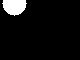
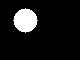

In [10]:
neighborhood_mask = make_neighborhood_mask(feats_height, feats_width, size=12, shape="circle")

mp.show_images(
    {f"{(i, j)}": neighborhood_mask[i, j].cpu().numpy() for i, j in [[3, 14], [20, 25]]},
    height=DISPLAY_HEIGHT,
)

To understand how it works, let's do it for one frame only.
The "context" contains only the first frame and the "current frame" is the second one.

In [11]:
torch._dynamo.maybe_mark_dynamic(first_frame, (1, 2))
first_feats = forward(model, first_frame)  # [h, w, D]
print(f"First feats:   {first_feats.shape}")

frame_idx = 1
current_frame_pil = frames[frame_idx]
current_frame = transform(current_frame_pil).to("cuda")  # [3, H, W]
torch._dynamo.maybe_mark_dynamic(current_frame, (1, 2))
current_feats = forward(model, current_frame)  # [h", w", D]
print(f"Current feats: {current_feats.shape}")

current_probs = propagate(
    current_feats,  # [h", w", D]
    context_features=first_feats.unsqueeze(0),  # [1, h, w, D]
    context_probs=first_probs.unsqueeze(0),  # [1, h, w, M]
    neighborhood_mask=neighborhood_mask,  # [h", w", h, w]
    topk=5,
    temperature=0.2,
)  # [h", w", M]
print(f"Current probs:  {current_probs}")

First feats:   torch.Size([60, 80, 1024])
Current feats: torch.Size([60, 80, 1024])
Current probs:  tensor[60, 80, 6] n=28800 (0.1Mb) x∈[0., 1.000] μ=0.167 σ=0.371 cuda:0


Then, we upsample the predicted probabilities and postprocess them.

Finally, we visualize:
- The first frame with its ground truth next to the second frame with the predicted masks.
- The per-mask probabilties predicted for the second frame.

First frame,Second frame
,

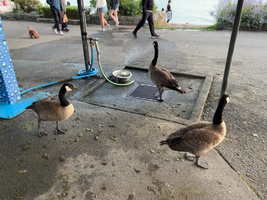
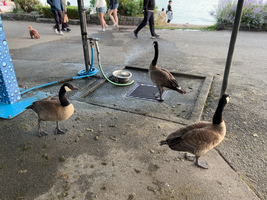
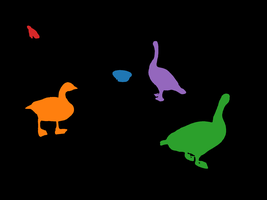
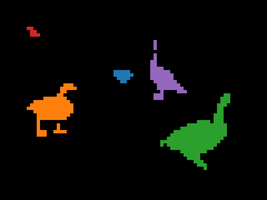

Mask 0,Mask 1,Mask 2,Mask 3,Mask 4,Mask 5

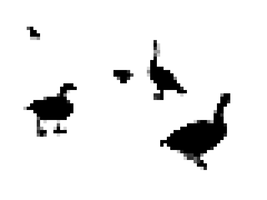
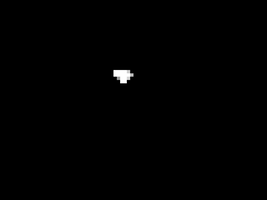
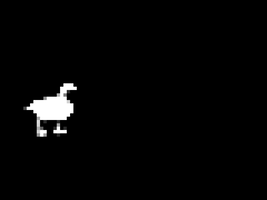
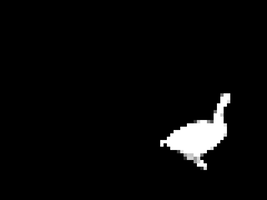
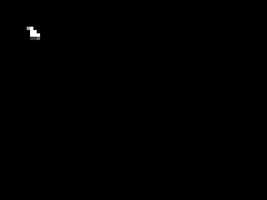
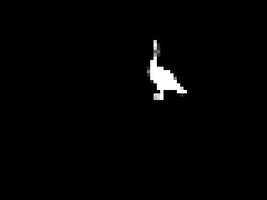

In [12]:
def postprocess_probs(
    probs: Tensor,  # [B, M, H', W']
) -> Tensor:
    vmin = probs.flatten(2, 3).min(dim=2).values  # [B, M]
    vmax = probs.flatten(2, 3).max(dim=2).values  # [B, M]
    probs = (probs - vmin[:, :, None, None]) / (vmax[:, :, None, None] - vmin[:, :, None, None])
    probs = torch.nan_to_num(probs, nan=0)
    return probs  # [B, M, H', W']


p = current_probs.movedim(-1, -3).unsqueeze(0)  # [1, M, h", w"]
p = F.interpolate(p, size=(mask_height, mask_width), mode="nearest")  # [1, M, H', W']
p = postprocess_probs(p).squeeze(0)  # [M, H', W']
current_pred_np = p.argmax(0).cpu().numpy()  # [H', W']
current_probs_np = p.cpu().numpy()  # [M, H', W']
del p

mp.show_images(
    [
        frames[0],
        current_frame_pil,
        mask_to_rgb(first_mask_np, num_masks),
        mask_to_rgb(current_pred_np, num_masks),
    ],
    titles=["First frame", "Second frame", "", ""],
    columns=2,
    height=DISPLAY_HEIGHT,
)

mp.show_images(current_probs_np, titles=[f"Mask {i}" for i in range(num_masks)], height=DISPLAY_HEIGHT)

## Process video

All clear? Time to do it for real!

This time we will process all frames, using a queue of context frames and a queue context mask probabilities.
The queues will contain a limited number of the most recent frames, determined by `max_context_length`.
The first frame is always included in the context and doesn't need to go in the queue.

Let's define all hyperparameters in one place.

In [13]:
MAX_CONTEXT_LENGTH = 7
NEIGHBORHOOD_SIZE = 12
NEIGHBORHOOD_SHAPE = "circle"
TOPK = 5
TEMPERATURE = 0.2

Let's go!

The predicted mask probabilities and the masks, at the original mask resolution, will be stored in `mask_predictions` and `mask_probabilities`.

In [ ]:
mask_predictions = torch.zeros([num_frames, mask_height, mask_width], dtype=torch.uint8)  # [T, H', W']
mask_predictions[0, :, :] = torch.from_numpy(first_mask_np)

mask_probabilities = torch.zeros([num_frames, num_masks, mask_height, mask_width])  # [T, M, H', W']
mask_probabilities[0, :, :, :] = F.one_hot(torch.from_numpy(first_mask_np).long(), num_masks).movedim(-1, -3)

# feature 해상도 확률맵 저장 (JBU 등 후처리 업샘플 입력용). 작음: [T, M, h, w]
probs_lowres = torch.zeros([num_frames, num_masks, feats_height, feats_width])  # [T, M, h, w]
probs_lowres[0] = first_probs.movedim(-1, -3).cpu()

features_queue: list[Tensor] = []
probs_queue: list[Tensor] = []

neighborhood_mask = make_neighborhood_mask(
    feats_height,
    feats_width,
    size=NEIGHBORHOOD_SIZE,
    shape=NEIGHBORHOOD_SHAPE,
)  # [h", w", h, w]

start = time.perf_counter()
for frame_idx in tqdm(range(1, num_frames), desc="Processing"):
    # Extract features for the current frame
    current_frame_pil = frames[frame_idx]
    current_frame = transform(current_frame_pil).to("cuda")  # [3, H, W]
    torch._dynamo.maybe_mark_dynamic(current_frame, (1, 2))
    current_feats = forward(model, current_frame)  # [h", w", D]

    # Prepare the context, marking the time and mask dimensions as dynamic for torch compile
    context_feats = torch.stack([first_feats, *features_queue], dim=0)  # [1+len(queue), h, w, D]
    context_probs = torch.stack([first_probs, *probs_queue], dim=0)  # [1+len(queue), h, w, M]
    torch._dynamo.maybe_mark_dynamic(context_feats, 0)
    torch._dynamo.maybe_mark_dynamic(context_probs, (0, 3))

    # Propagate segmentation probs from context frames
    current_probs = propagate(
        current_feats,
        context_feats,
        context_probs,
        neighborhood_mask,
        TOPK,
        TEMPERATURE,
    )  # [h", w", M]

    # Update queues with current features and probs
    features_queue.append(current_feats)
    probs_queue.append(current_probs)
    if len(features_queue) > MAX_CONTEXT_LENGTH:
        features_queue.pop(0)
    if len(probs_queue) > MAX_CONTEXT_LENGTH:
        probs_queue.pop(0)

    # feature 해상도 확률맵 저장 (업샘플 전, JBU 입력용)
    probs_lowres[frame_idx] = current_probs.movedim(-1, -3).cpu()

    # Upsample and postprocess segmentation probs, argmax to obtain a prediction
    current_probs = F.interpolate(
        current_probs.movedim(-1, -3)[None, :, :, :],
        size=(mask_height, mask_width),
        mode="nearest",
    )  # [1, M, H', W']
    current_probs = postprocess_probs(current_probs)  # [1, M, H', W']
    current_probs = current_probs.squeeze(0)
    mask_probabilities[frame_idx, :, :, :] = current_probs
    pred = torch.argmax(current_probs, dim=0).to(dtype=torch.uint8)  # [H', W']
    mask_predictions[frame_idx, :, :] = pred  # [H', W']

torch.cuda.synchronize()
end = time.perf_counter()
print(f"Processing time:    {datetime.timedelta(seconds=round(end - start))}")
print(f"Mask probabilities: {mask_probabilities}")
print(f"Mask predictions:   {mask_predictions}")

## (선택) 후처리 prior — 영역 내부 particle/구멍 메우기

propagate 는 particle 을 appearance 로 **정확히** 감지해 영역에서 제외합니다. 하지만
"영역 내부의 작은 이물은 여전히 그 영역"이라는 건 feature 가 주지 않는 **형태학적 사전지식**이에요.
이를 **최종 출력 마스크에만** 적용합니다 (tracking/context queue 에는 영향 없음 → 오차 누적 방지).

- `FILL_HOLES`: 영역에 완전히 둘러싸인 구멍(=내부 particle)을 **크기 무관** 전부 메움.
- `CLOSING_RADIUS`: >0 이면 반지름 R(px) disk 로 closing → 경계에 걸친 홈/이물도 최대 ~2R 까지 메움.
  **R 이 곧 "허용할 particle 최대 크기" 노브.** 둘은 병용 가능.

`mask_predictions_pp` 로 따로 저장하니 raw(`mask_predictions`)와 비교해 민감도를 조절하세요.

In [ ]:
# ── 후처리 prior: 영역 내부 particle/구멍 메우기 (출력 마스크에만 적용) ──────
from scipy import ndimage as ndi

# 노브 (여기만 조절)
FILL_HOLES = True       # 영역에 둘러싸인 내부 구멍 전부 메움 (particle 크기 무관)
CLOSING_RADIUS = 0      # >0: 반지름 R px disk closing. = 허용할 particle 최대 크기


def _disk(r: int) -> np.ndarray:
    yy, xx = np.ogrid[-r:r + 1, -r:r + 1]
    return (xx * xx + yy * yy) <= r * r


def postprocess_masks(pred_stack: torch.Tensor, num_masks: int) -> torch.Tensor:
    """[T,H',W'] uint8 (0=bg, 1..M-1=instance) → 인스턴스별 fill_holes/closing 후 재조합."""
    struct = _disk(CLOSING_RADIUS) if CLOSING_RADIUS > 0 else None
    out = pred_stack.clone()
    T = pred_stack.shape[0]
    for t in range(T):
        p = pred_stack[t].numpy()
        res = np.zeros_like(p)
        for lab in range(1, num_masks):           # 배경(0) 제외, 라벨별 처리
            m = p == lab
            if not m.any():
                continue
            if struct is not None:
                m = ndi.binary_closing(m, structure=struct)
            if FILL_HOLES:
                m = ndi.binary_fill_holes(m)
            res[m] = lab                            # 겹치면 큰 라벨 우선 (단일 영역이면 무관)
        out[t] = torch.from_numpy(res.astype(np.uint8))
    return out


mask_predictions_pp = postprocess_masks(mask_predictions, num_masks)
# 첫 프레임은 GT 그대로 유지
mask_predictions_pp[0] = mask_predictions[0]

changed = (mask_predictions_pp != mask_predictions).float().mean().item()
print(f"후처리 완료 (FILL_HOLES={FILL_HOLES}, CLOSING_RADIUS={CLOSING_RADIUS})")
print(f"변경된 픽셀 비율: {changed * 100:.3f}%  → mask_predictions_pp 에 저장")

# raw vs 후처리 비교 (선택 프레임)
mp.show_images(
    [mask_to_rgb(mask_predictions[i], num_masks) for i in selected_frames]
    + [mask_to_rgb(mask_predictions_pp[i], num_masks) for i in selected_frames],
    titles=[f"raw {i}" for i in selected_frames] + [f"pp {i}" for i in selected_frames],
    columns=len(selected_frames),
    height=DISPLAY_HEIGHT,
)

## (선택) JBU — Joint Bilateral Upsampling (엣지 정렬 업샘플, 학습 X)

propagation 은 feature 해상도(≈60×80)에서 일어나 마스크 경계가 patch 단위로 계단집니다.
JBU 는 **원본 RGB 프레임을 guide** 로 써서 저해상도 확률맵(`probs_lowres`)을 원본 해상도로
**엣지에 정렬해** 업샘플합니다. FeatUp 의 JBU 변형과 동일 원리이고 **학습이 필요 없어요**.

각 고해상도 픽셀 p 는 대응 저해상도 이웃 q 들의 확률을 두 가중치로 합칩니다:
- **spatial**: p–q 거리 (patch 단위 gaussian, `JBU_SIGMA_SPATIAL`)
- **range**: guide 색 차이 |I(p) − I(q)| gaussian (`JBU_SIGMA_RANGE`) → **엣지를 넘는 이웃은 배제**

파라미터:
- `JBU_RADIUS` (저해상도 이웃 반경, 1 → 3×3)
- `JBU_SIGMA_SPATIAL` (patch 단위, 클수록 부드럽게)
- `JBU_SIGMA_RANGE` (0..1 RGB 색차, 작을수록 엣지에 더 민감하게 딱 붙음)
- `APPLY_MORPH_ON_JBU`: JBU 결과에 위 형태학 후처리(fill/closing)도 이어서 적용

결과는 `mask_predictions_jbu` / `mask_probabilities_jbu` 로 저장 → raw 와 비교.

In [ ]:
# ── JBU 파라미터 (여기만 조절) ────────────────────────────────────────────
JBU_RADIUS = 1            # 저해상도 이웃 반경 (1 → 3x3, 2 → 5x5)
JBU_SIGMA_SPATIAL = 1.0   # patch 단위 spatial gaussian σ (클수록 부드럽게)
JBU_SIGMA_RANGE = 0.10    # guide 색차 σ (0..1 RGB, 작을수록 엣지에 딱 붙음)
APPLY_MORPH_ON_JBU = True # JBU 후 위 형태학 후처리(fill_holes/closing)도 적용


@torch.inference_mode()
def jbu_upsample(probs_lr: Tensor, guide_hr: Tensor,
                 radius: int, sigma_spatial: float, sigma_range: float) -> Tensor:
    """Joint Bilateral Upsampling.
    probs_lr: [M, h, w] (0..1), guide_hr: [3, H, W] (0..1) → [M, H, W]."""
    M, h, w = probs_lr.shape
    _, H, W = guide_hr.shape
    dev = probs_lr.device
    guide_lr = F.interpolate(guide_hr[None], size=(h, w), mode="area")[0]  # [3, h, w]

    # 각 고해상도 픽셀의 저해상도 연속 좌표
    gy = (torch.arange(H, device=dev) + 0.5) * (h / H) - 0.5  # [H]
    gx = (torch.arange(W, device=dev) + 0.5) * (w / W) - 0.5  # [W]
    gy, gx = torch.meshgrid(gy, gx, indexing="ij")            # [H, W]
    by, bx = torch.floor(gy).long(), torch.floor(gx).long()

    probs_flat = probs_lr.reshape(M, -1)   # [M, h*w]
    guide_flat = guide_lr.reshape(3, -1)   # [3, h*w]
    num = torch.zeros(M, H, W, device=dev)
    den = torch.zeros(1, H, W, device=dev)
    for di in range(-radius, radius + 1):
        for dj in range(-radius, radius + 1):
            iy, ix = by + di, bx + dj
            valid = (iy >= 0) & (iy < h) & (ix >= 0) & (ix < w)  # [H, W]
            flat = (iy.clamp(0, h - 1) * w + ix.clamp(0, w - 1)).reshape(-1)  # [H*W]
            p_k = probs_flat[:, flat].reshape(M, H, W)
            g_k = guide_flat[:, flat].reshape(3, H, W)
            d2 = (gy - iy.float()) ** 2 + (gx - ix.float()) ** 2              # spatial
            ws = torch.exp(-d2 / (2 * sigma_spatial ** 2))
            dr2 = ((guide_hr - g_k) ** 2).sum(0)                             # range
            wr = torch.exp(-dr2 / (2 * sigma_range ** 2))
            wk = (ws * wr * valid.float())[None]                            # [1, H, W]
            num += p_k * wk
            den += wk
    return num / (den + 1e-8)  # [M, H, W]


mask_probabilities_jbu = torch.zeros_like(mask_probabilities)
mask_predictions_jbu = torch.zeros_like(mask_predictions)
for t in tqdm(range(num_frames), desc="JBU"):
    guide = TVTF.to_tensor(frames[t]).to("cuda")          # [3, H, W] 0..1
    plr = probs_lowres[t].to("cuda")                       # [M, h, w]
    up = jbu_upsample(plr, guide, JBU_RADIUS, JBU_SIGMA_SPATIAL, JBU_SIGMA_RANGE)  # [M, H, W]
    mask_probabilities_jbu[t] = up.cpu()
    mask_predictions_jbu[t] = up.argmax(0).to(torch.uint8).cpu()
mask_predictions_jbu[0] = mask_predictions[0]  # 첫 프레임 GT 유지

if APPLY_MORPH_ON_JBU:
    mask_predictions_jbu = postprocess_masks(mask_predictions_jbu, num_masks)
    mask_predictions_jbu[0] = mask_predictions[0]

print(f"JBU 완료 (radius={JBU_RADIUS}, σ_s={JBU_SIGMA_SPATIAL}, σ_r={JBU_SIGMA_RANGE}, "
      f"morph={APPLY_MORPH_ON_JBU})")

# raw(nearest) vs JBU 경계 비교
mp.show_images(
    [mask_to_rgb(mask_predictions[i], num_masks) for i in selected_frames]
    + [mask_to_rgb(mask_predictions_jbu[i], num_masks) for i in selected_frames],
    titles=[f"nearest {i}" for i in selected_frames] + [f"JBU {i}" for i in selected_frames],
    columns=len(selected_frames),
    height=DISPLAY_HEIGHT,
)

Let's visualize a few frames and a video of the result.

In [ ]:
import mediapy as mp

# 실행한 후처리 결과들을 자동으로 함께 표시.
_variants = [("raw", mask_predictions)]
if "mask_predictions_pp" in globals():
    _variants.append(("pp", mask_predictions_pp))
if "mask_predictions_jbu" in globals():
    _variants.append(("jbu", mask_predictions_jbu))

mp.show_images(
    [frames[i].convert("RGB") for i in selected_frames]
    + [mask_to_rgb(m[i], num_masks) for _, m in _variants for i in selected_frames],
    titles=[f"Frame {i}" for i in selected_frames]
    + [f"{name} {i}" for name, m in _variants for i in selected_frames],
    columns=len(selected_frames),
    height=DISPLAY_HEIGHT,
)

_videos = {"Input": [np.array(frame) for frame in frames]}
for name, m in _variants:
    _videos[f"Pred ({name})"] = mask_to_rgb(m, num_masks)
mp.show_videos(_videos, height=DISPLAY_HEIGHT, fps=24)

mp.show_videos(
    {f"Prob {i}": mask_probabilities[:, i].numpy() for i in range(num_masks)},
    height=DISPLAY_HEIGHT,
    fps=24,
)

# Conclusion

This notebook showed how to use DINOv3 for video segmentation tracking.
It should be fairly straightforward to run it to your own video and masks.
The notebook hyperparameters can also be adjusted to see the effect on the results.

Let's discuss GPU memory usage:
- The ViT-L model takes approximately 1.1 GB to load.
- The similarity matrix `dot` inside `propagate()` can get pretty big,
  especially at higher resolution and longer context length.

To reduce memory usage and increase speed, the notebook is already set up to work with `torch.compile()`.
In particular, note the use of `torch._dynamo.maybe_mark_dynamic()` to mark a few dimensions as dynamic
to avoid too many recompilations. To enable compilation, just set `disable` to `False` in the
`@torch.compile()` decorators for the `propagate()` and `forward()` functions.

If you are low on memory, it also possible to use a smaller model and
reduce the forward resolution, but tracking results will look worse.

In [16]:
print(f"Peak GPU memory: {torch.cuda.max_memory_allocated() / 2**30:.1f} GB")

Peak GPU memory: 3.6 GB
